<a href="https://colab.research.google.com/github/Thanni914/5004-PROJECT-BIG-DATA/blob/main/work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
!pip install "dask[complete]"

In [31]:
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import time
from dask.distributed import Client


big_dataset = dd.read_csv('/content/drive/MyDrive/5004CMD_PROJECT/Trips_Full_Data.csv')

small_dataset_dtypes = {
    'County Name': 'object',
    'Number of Trips': 'float64',
    'Number of Trips 1-3': 'float64',
    'Number of Trips 10-25': 'float64',
    'Number of Trips 100-250': 'float64',
    'Number of Trips 25-50': 'float64',
    'Number of Trips 250-500': 'float64',
    'Number of Trips 3-5': 'float64',
    'Number of Trips 5-10': 'float64',
    'Number of Trips 50-100': 'float64',
    'Number of Trips <1': 'float64',
    'Number of Trips >=500': 'float64',
    'Population Not Staying at Home': 'float64',
    'Population Staying at Home': 'float64',
    'State Postal Code': 'object'
}
small_dataset = dd.read_csv('/content/drive/MyDrive/5004CMD_PROJECT/Trips_by_Distance.csv', dtype=small_dataset_dtypes, parse_dates=['Date'])

national_only = big_dataset[big_dataset['Level'] == "National"]


# Removed the line attempting to drop non-existent columns.

print("Data loaded and cleaned successfully BUDDY!")

Data loaded and cleaned successfully BUDDY!


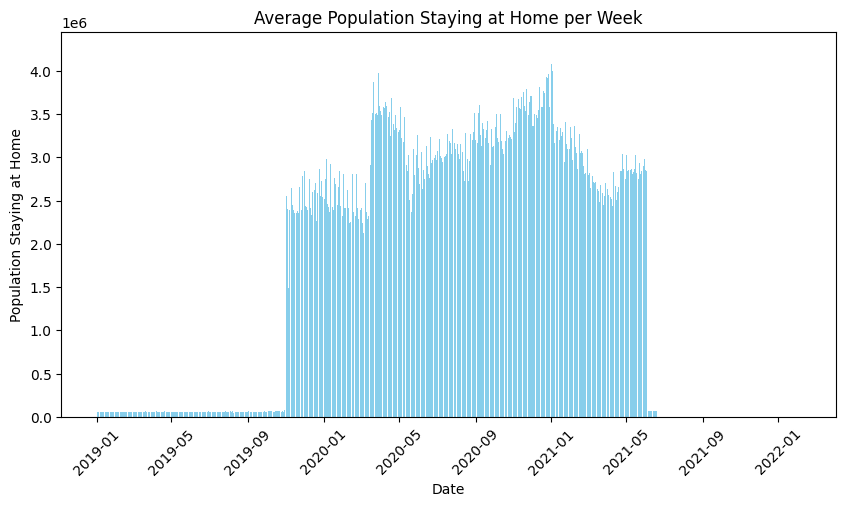

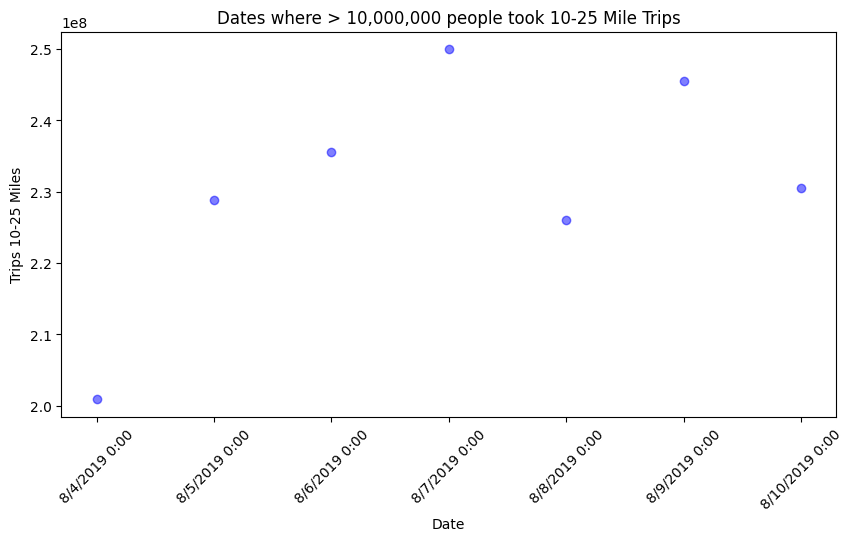

In [35]:
# QUESTION 1: Stay at Home vs Travel. done!!!
start_date = small_dataset['Date'].min().compute()
end_date = small_dataset['Date'].max().compute()

# Only dropping 'Level' as the other specific columns aren't in small_dataset
clean_small = small_dataset.drop(columns=["Level"])

grouped_data = clean_small[['Date', 'Population Staying at Home']].groupby('Date').mean().reset_index().compute()

plt.figure(figsize=(10,5))
plt.bar(grouped_data['Date'], grouped_data['Population Staying at Home'], color='skyblue')
plt.xlabel('Date')
plt.ylabel('Population Staying at Home')
plt.title('Average Population Staying at Home per Week')
plt.xticks(rotation=45)
plt.show()

# --- QUESTION 2: High Frequency Travel Dates. Done!!!

q2_data = national_only[['Trips 10-25 Miles', 'Trips 50-100 Miles', 'Date']]
set1 = q2_data[q2_data['Trips 10-25 Miles'] > 10000000].compute()
set2 = q2_data[q2_data['Trips 50-100 Miles'] > 10000000].compute()

plt.figure(figsize=(10,5))
plt.scatter(set1['Date'], set1['Trips 10-25 Miles'], color='blue', alpha=0.5)
plt.title('Dates where > 10,000,000 people took 10-25 Mile Trips')
plt.xlabel('Date')
plt.ylabel('Trips 10-25 Miles')
plt.xticks(rotation=45)
plt.show()

CRITICAL METRIC - Coefficient of Determination (R^2): 1.048148894466916e-05


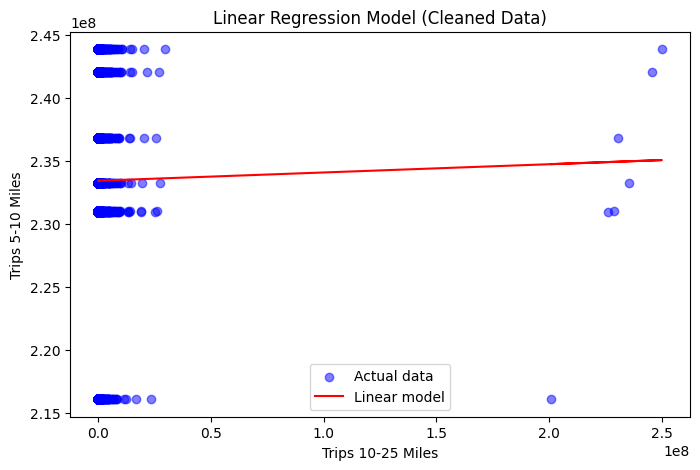

In [38]:
national_only['Date'] = dd.to_datetime(national_only['Date'])


df_x = small_dataset[['Date', 'Number of Trips 10-25']].compute()
df_y = national_only[national_only['Date'].between(start_date, end_date)][['Date', 'Trips 5-10 Miles']].compute()

combined = pd.merge(df_x, df_y, on='Date').dropna()

x_model = combined[['Number of Trips 10-25']].values
y_model = combined[['Trips 5-10 Miles']].values

if len(combined) > 0:
    model = LinearRegression()
    model.fit(x_model, y_model)

    r_sq = model.score(x_model, y_model)
    print(f"CRITICAL METRIC - Coefficient of Determination (R^2): {r_sq}")

    y_pred_linear = model.predict(x_model)
    plt.figure(figsize=(8,5))
    plt.scatter(x_model, y_model, color='blue', label='Actual data', alpha=0.5)
    plt.plot(x_model, y_pred_linear, color='red', label='Linear model')
    plt.xlabel('Trips 10-25 Miles')
    plt.ylabel('Trips 5-10 Miles')
    plt.title('Linear Regression Model (Cleaned Data)')
    plt.legend()
    plt.show()
else:
    print("Error: No overlapping data points found between the two datasets for the selected date range.")

In [40]:
def run_dummy_workload():
    national_only['Trips 10-25 Miles'].mean().compute()

n_processors = [1, 10, 20]
for processor in n_processors:
    print(f"Starting computation with {processor} processors...")
    client = Client(n_workers=processor, threads_per_worker=1)

    start = time.time()
    run_dummy_workload()
    elapsed_time = time.time() - start

    print(f"Time with {processor} processors: {elapsed_time:.2f} seconds")
    client.close()

/usr/local/lib/python3.12/dist-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35893 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:40315
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:35893/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:43383'


Starting computation with 1 processors...


INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:44639 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:44639
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:34020
INFO:distributed.scheduler:Receive client connection: Client-4eb5c941-2cb3-11f1-8d1b-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:34022
INFO:distributed.scheduler:Remove client Client-4eb5c941-2cb3-11f1-8d1b-0242ac1c000c
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:34022; closing.
INFO:distributed.scheduler:Remove client Client-4eb5c941-2cb3-11f1-8d1b-0242ac1c000c
INFO:distributed.scheduler:Close client connection: Client-4eb5c941-2cb3-11f1-8d1b-0242ac1c000c
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1774928408.2263534') (0,)
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:43383'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker t

Time with 1 processors: 1.77 seconds


INFO:distributed.nanny:Nanny at 'tcp://127.0.0.1:43383' closed.
INFO:distributed.scheduler:Closing scheduler. Reason: unknown
INFO:distributed.scheduler:Scheduler closing all comms
/usr/local/lib/python3.12/dist-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40307 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:35963
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:40307/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:36473'


...

INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:39670; closing.
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:39648; closing.
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:39662; closing.
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:39710; closing.
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:39700; closing.
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:39682; closing.
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:39688; closing.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:44283 name: 1 (stimulus_id='handle-worker-cleanup-1774928420.9850092')
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:33359 name: 0 (stimulus_id='handle-worker-cleanup-1774928421.0038624')
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:34915 name: 2 (stimulus_id='handle-worker-cleanup-1774928421.0165303')
INFO:distributed.

Starting computation with 20 processors...


INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44947'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44679'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:32865'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:32987'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:46691'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:39733'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:37321'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:41255'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34661'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34095'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40755'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34135'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40937'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34545'
INFO:d

Time with 20 processors: 8.54 seconds


INFO:distributed.scheduler:Remove client Client-589fdcd4-2cb3-11f1-8d1b-0242ac1c000c
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:46512; closing.
INFO:distributed.scheduler:Remove client Client-589fdcd4-2cb3-11f1-8d1b-0242ac1c000c
INFO:distributed.scheduler:Close client connection: Client-589fdcd4-2cb3-11f1-8d1b-0242ac1c000c
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1774928448.8663814') (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19)
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:40323'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:44947'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:44679'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO: